In [1]:
package Flashlight_StarterModel{
    // ran with 2024-01 on 2024-02-07
     /* The following is a simple flashlight model that is intended to introduce modelers to SysML v2.
     The scope includes some basic language features used to model system requirements, behavior, and structure.
     This model contains usage elements with limited use of definition elements to simplify the example.
     It is anticipated that a user will review and modify this model in their modeling environment.
     As an example, a modification could include updating the flashlight requirments and design to add a flashing state.
     
     Refer to the following URL r instructional material on SysML v2 textual and graphical syntax: 
     https://github.com/Systems-Modeling/SysML-v2-Release/tree/master/doc
     
     The SysML v2 graphical notation is illustrated using the PlantUML integration in Jupyter with some simple viz commands.
     */

    import ScalarValues::*; // Import the ScalarValues library to provide the basic data types such as Integer, Real, String, and Boolean
    // the following are examples of attribute data types that can be used in a systems model
    attribute x1 : Integer = 1; // the symbol ":" is a shorthand for the keywords "defined by"
    attribute x2 : Real = 3.3;
    attribute x3 : Boolean = true;
    attribute x4 : String = "This is a String";

    // Import the SI library to provide the basic Standard International Units such as kg (i.e., kilograms) and m (i.e. meter)
    // This library also imports ISQ library which contains international system of quantities such as length, time, power, ...
    import SI::*;//the command "::*" imports the entire library
    // the following are examples
    attribute y1 :> ISQ::length = 3.0 [m]; // the symbol ":>" is a shorthand for the keyword "subsets"
    attribute y2 :> ISQ::mass = 100 [kg];

    // Import the USCustomaryUnits library to provide the basic US Customary Units such as lb (i.e., pound) and ft (i.e., foot)
    import USCustomaryUnits::*;
    // the following are examples
    attribute z1 :> USCustomaryUnits::length = 3.0 [ft];
    attribute z2 :> USCustomaryUnits::mass = 100 [lb];

    package FlashlightSpecificationAndDesign {

        // create a Requirements package that contains the hierarchy of requirements that compose the flashlight specification
        package Requirements{
            requirement flashlightSpecification{
                requirement userInterface;
                requirement illumination{
                    // the following is a simple text-based requirement
                    requirement fieldOfView{
                        doc /* The flashlight field of view shall be 0 - 20 degrees.*/
                    }
                    requirement lightPower{
                        doc /* The light power shall be a minumum of TBD lumens.*/            
                    }
                }
                requirement physical{
                    requirement portability;
                    requirement size{
                        doc /* The flashlight shall be less than 6 inches in length.*/    
                    }
                    // the following is a more precisely specified requirement using constraints
                    requirement weight{
                        doc /* The weight shall be less than 0.25 lbs.*/  
                        attribute actualWeight :> ISQ::mass;
                        require constraint {actualWeight <= 0.25 [lb]}
                    }
                }
                requirement reliability;
                requirement cost;
            }
        }

        // create a package called ActionTree that contains the actions and flows to produceDirectedLight
        package ActionTree{
            action produceDirectedLight{
                in item onOffCmd; //input
                // the following output (i.e., lightOut) from produceDirectedLight is equal to (i.e., bound to) the lightOut from the action directLight;
                out item lightOut = directLight.lightOut;

                // declare each nested action and their inputs and outputs
                action provideDCPwr{
                    out item dcPwr;
                }
                action connectDCPwr {
                    in item onOffCmd = produceDirectedLight.onOffCmd;
                    in item dcPwrIn;
                    out item dcPwrOut;
                }
                action generateLight{
                    in item dcPwrIn;
                    out item light;
                }
                action directLight{
                    in item lightIn;
                    out item lightOut;
                }
                // the following declares a fork node named fork1 that is succeeded by two parallel actions (provideDCPwr and connectDCPowr)
                fork fork1;
                    then provideDCPwr; // succession
                    then connectDCPwr; // succession

                // define a control flow (i.e., succession) beginning with a start node and then fork1
                // note that start node does not have to be declared. It is available by default.
                first start then fork1;

                // define input/output flow from the output of one action to the input of another action
                flow from provideDCPwr.dcPwr to connectDCPwr.dcPwrIn;
                flow from connectDCPwr.dcPwrOut to generateLight.dcPwrIn;
                flow from generateLight.light to directLight.lightIn;
            }
        }

        // create a PartsTree package that contains the flashlight,
        // along with its key features such as attributes, ports, and actions, its parts, and its part interconnections
        package PartsTree{ 
            part flashlight {
                // flashlight attributes
                attribute mass :> ISQ::mass;
                attribute fov:Real;
                attribute illuminationLevel:Real;

                // flashlight ports
                port cmdPort;
                port lightOutPort;

                // flashlight perform action. The flashlight performs the action called produceDirectedLight 
                // that is contained in the Action Tree
                perform ActionTree::produceDirectedLight;    

                // the flashlight exhibits its flashlight states wich are initial, off, and on;
                exhibit state flashlightStates{
                    // declare the states
                    state initial;
                    state off;                                 
                    state on{
                        // define the do action by referring to (actually subsetting) 
                        // the action above 'perfrom ActionTree::produceDirectedLight'
                        do produceDirectedLight;
                    }

                    // each of the state transitions is defined
                    // the transitions just specify the start and end states of the transition
                    // the triggering events are not included for simplicity
                    transition initial then off;
                    transition off_To_on
                        first off
                        then on;
                    transition on_To_off
                        first on
                        then off;
                }
                // the battery is a referential part of the flashlight
                ref part battery [2]{ // the multiplicity of 2 signifies that a flashlight has 2 batteries.
                    attribute power:> ISQ::power;
                    port dcPwrOutPort;
                    perform produceDirectedLight.provideDCPwr;
                }
                // the following are composite parts of the flashlight
                part switch{
                    port cmdPort;
                    port inPort;
                    port outPort;
                    perform produceDirectedLight.connectDCPwr;
                }
                part lamp{
                    attribute efficiency:Real;
                    port dcPwrInPort;
                    port lightOutPort;
                    perform produceDirectedLight.generateLight;
                }
                part optics{
                    port lightInPort;
                    port lightOutPort;
                    perform produceDirectedLight.directLight;
                    part reflector{
                        attribute radius:> ISQ::length;
                    }
                    part lens;
                }
                part structure{
                    part frontHousing;
                    part middleHousing;
                    part backHousing;
                }

                // the following establish connections
                // the binding connections assert that the cmdPort on the flashlight is the same as the cmdPort on the switch
                // and similarly for the lightOutPort
                bind cmdPort = switch.cmdPort;
                bind lightOutPort = optics.lightOutPort;

                // the connections connect a port on one part to a port to on another part
                connect battery.dcPwrOutPort to switch.inPort;
                connect switch.outPort to lamp.dcPwrInPort; 
                connect lamp.lightOutPort to optics.lightInPort;
            }
        }
        // create an RequirementsAllocation package that contains the allocation of requirements to the flashlight design features
        package RequirementsAllocation{
            // this package imports the Requirements package and the PartsTree packge to access the elements contained in these packages
            // without having to use their fully qualified name such as Requirements::flashlightSpecification
            import Requirements::*;
            import PartsTree::*;

            // the following allocates the flashlightSpecification to the flashlight
            allocate flashlightSpecification to flashlight{
                allocate flashlightSpecification.physical.weight to flashlight.mass; // nested allocation
                allocate flashlightSpecification.illumination.fieldOfView to flashlight.fov;
                allocate flashlightSpecification.illumination.lightPower to flashlight.illuminationLevel;
            }
        }
    }
    // the following are subsets of the above model to create the graphical rendering
    // this is a limitation of the pilot implementation's visualization - a commercial tool would do this for you
    package SimplifiedViews{
        package FlashlightSpecAndDesign{
            package Requirements;
            package ActionTree;
            package PartsTree;
            package RequirementsAllocation;
        }
        package Requirements{
            requirement flashlightSpecification{
                requirement userInterface;
                requirement illumination{
                    // the following is a simple text based requirement
                    requirement fieldOfView{
                        doc /* The flashlight field of view shall be 0 - 20 degrees.*/
                    }
                    requirement lightPower{
                        doc /* The light power shall be a minumum of TBD lumens.*/            
                    }
                }
                requirement physical{
                    requirement portability;
                    requirement size{
                        doc /* The flashlight shall be less than 6 inches in length.*/    
                    }
                    // the following is a more precisely specified requirement using constraints
                    requirement weight{
                        doc /* The weight shall be less than 0.25 lbs.*/  
                        attribute actualWeight :> ISQ::mass;
                        require constraint {actualWeight <= 0.25 [lb]}
                    }
                }
                requirement reliability;
                requirement cost;
            }
        }
        package ActionTree{
            action produceDirectedLight{
                in item onOffCmd;
                out item lightOut;

                action provideDCPwr{
                    out item dcPwr;
                }
                action connectDCPwr {
                    in item onOffCmd;
                    in item dcPwrIn;
                    out item dcPwrOut;
                }
                action generateLight{
                    in item dcPwrIn;
                    out item light;
                }
                action directLight{
                    in item lightIn;
                    out item lightOut;
                }

                fork fork1;
                    // then provideDCPwr;
                    // then connectDCPwr;
            }
        }
        package PartsTree{
            part flashlight {
                // flashlight attributes
                attribute mass :> ISQ::mass;
                attribute fov:Real;
                attribute illuminationLevel:Real;

                // flashlight ports
                port cmdPort;
                port lightOutPort;

                ref part battery [2]{
                    attribute power:> ISQ::power;
                    port dcPwrOutPort;
                }
                part switch{
                    port cmdPort;
                    port inPort;
                    port outPort;
                }
                part lamp{
                    attribute efficiency:Real;
                    port dcPwrInPort;
                    port lightOutPort;
                }
                part optics{
                    port lightInPort;
                    port lightOutPort;
                    part reflector{
                        attribute radius:> ISQ::length;
                    }
                    part lens;
                }
                part structure{
                    part frontHousing;
                    part middleHousing;
                    part backHousing;
                }
            }
        }
        package States{
            part flashlight {
                // flashlight attributes
                attribute mass :> ISQ::mass;
                attribute fov:Real;
                attribute illuminationLevel:Real;

                port cmdPort;
                port lightOutPort;

                perform ActionTree::produceDirectedLight;    

                exhibit state flashlightStates{
                    // declare the states
                    state initial;
                    state off;                                 
                    state on {
                        do produceDirectedLight;
                    }
                    transition initial then off;
                    transition off_To_on
                        first off
                        then on;
                    transition on_To_off
                        first on
                        then off;
                }
            }
        }
        package RequirementsAllocation{
            requirement flashlightSpecification{
                requirement userInterface;
                requirement illumination{
                    // the following is a simple text based requirement
                    requirement fieldOfView{
                        doc /* The flashlight field of view shall be 0 - 20 degrees.*/
                    }
                    requirement lightPower{
                        doc /* The light power shall be a minumum of TBD lumens.*/            
                    }
                }
                requirement physical{
                    requirement portability;
                    requirement size{
                        doc /* The flashlight shall be less than 6 inches in length.*/    
                    }
                    // the followiing is a more precisely specified requirement using constraints
                    requirement weight{
                        doc /* The weight shall be less than 0.25 lbs.*/  
                        attribute actualWeight :> ISQ::mass;
                        require constraint {actualWeight <= 0.25 [lb]}
                    }
                }
                requirement reliability;
                requirement cost;
            }
            part flashlight {
                // flashlight attributes
                attribute mass :> ISQ::mass;
                attribute fov:Real;
                attribute illuminationLevel:Real;
            }
            allocate flashlightSpecification to flashlight{
                allocate flashlightSpecification.physical.weight to flashlight.mass;
                allocate flashlightSpecification.illumination.fieldOfView to flashlight.fov;
                allocate flashlightSpecification.illumination.lightPower to flashlight.illuminationLevel;
            }
        }
    }
}




Package Flashlight_StarterModel (feda38b5-6485-40af-a483-e7f66d5292c5)


In [2]:
%viz

Usage: %viz [--view=<VIEW>] [--style=<STYLE>...] <NAME> [<NAME>...]

Visualize model elements of <NAME>(s). <NAME>s must be fully qualified.

<VIEW> is case insensitive and possible candidates are:
   DEFAULT		Automatically choose an appropriate view from the given model element names
   TREE			Show a tree-structural view, like a Block Definition Diagram (BDD)
   INTERCONNECTION	Show an interconnection view, like an Internal Block Diagram (IBD)
   STATE		Show state machines
   ACTION		Show actions like an activity diagram
   SEQUENCE		Show events and messages in a sequence diagram
   MIXED		Show multiple views

<STYLE> is also case insensitive. Multiple --style options are allowed.  The possible style names are:
  DEFAULT		Standard B&&W
  STDCOLOR		Standard style with colors
  PLANTUML		PlantUML Style
  TB			Top-to-Bottom orientation
  LR			Left-to-Right orientation
  POLYLINE		Polyline style
  ORTHOLINE		Orthogonal line style
  SHOWLIB		Show elements of the standard libraries
  SHOWIN

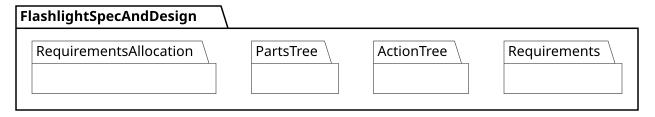

In [3]:
%viz --view tree Flashlight_StarterModel::SimplifiedViews::FlashlightSpecAndDesign

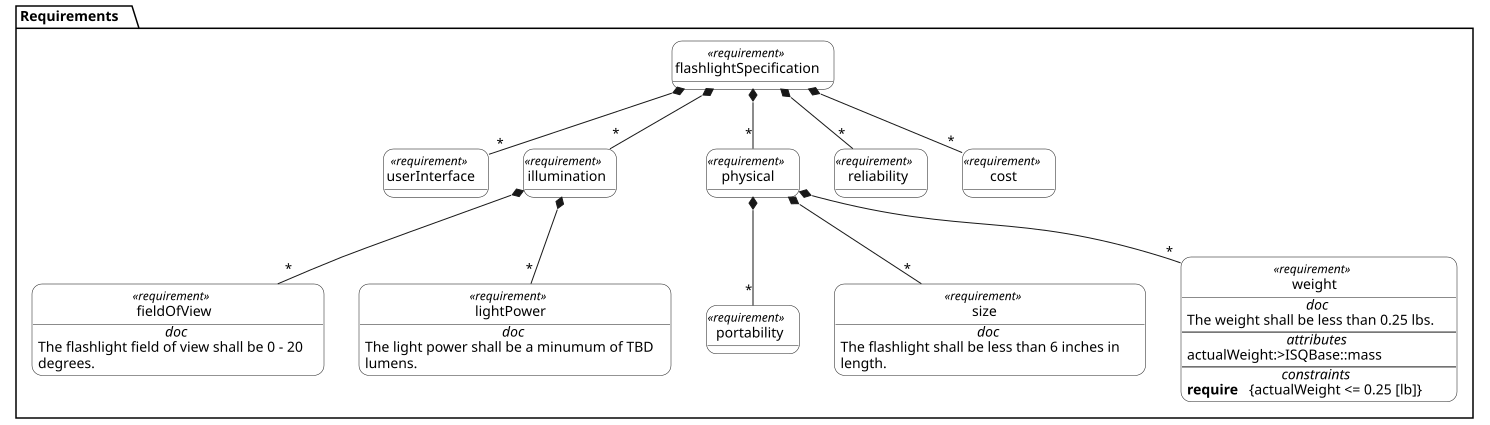

In [4]:
%viz --view tree Flashlight_StarterModel::SimplifiedViews::Requirements

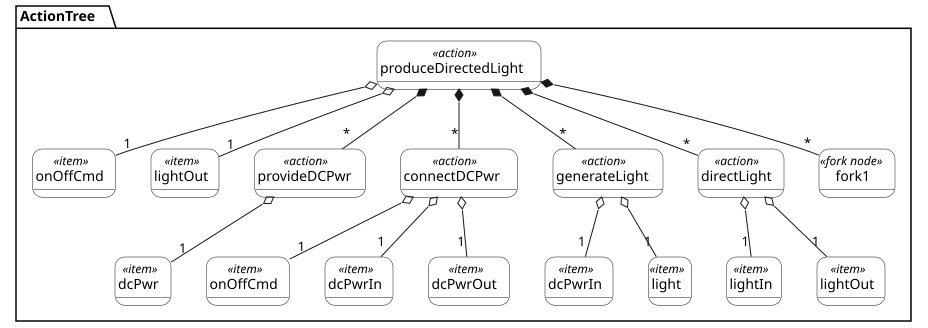

In [5]:
%viz --view tree Flashlight_StarterModel::SimplifiedViews::ActionTree

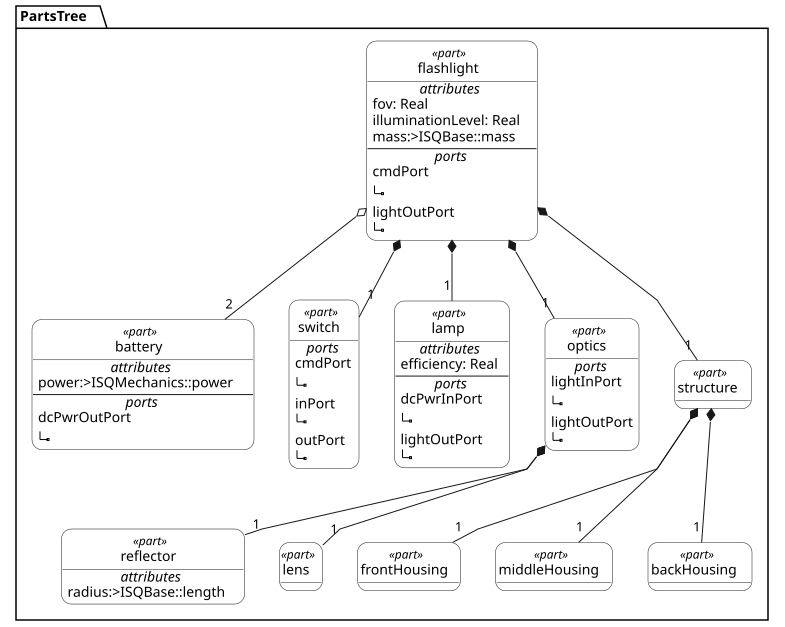

In [6]:
%viz --view tree --style comptree --style polyline Flashlight_StarterModel::SimplifiedViews::PartsTree

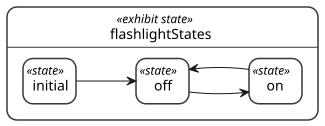

In [7]:
%viz --view state --style lr Flashlight_StarterModel::SimplifiedViews::States

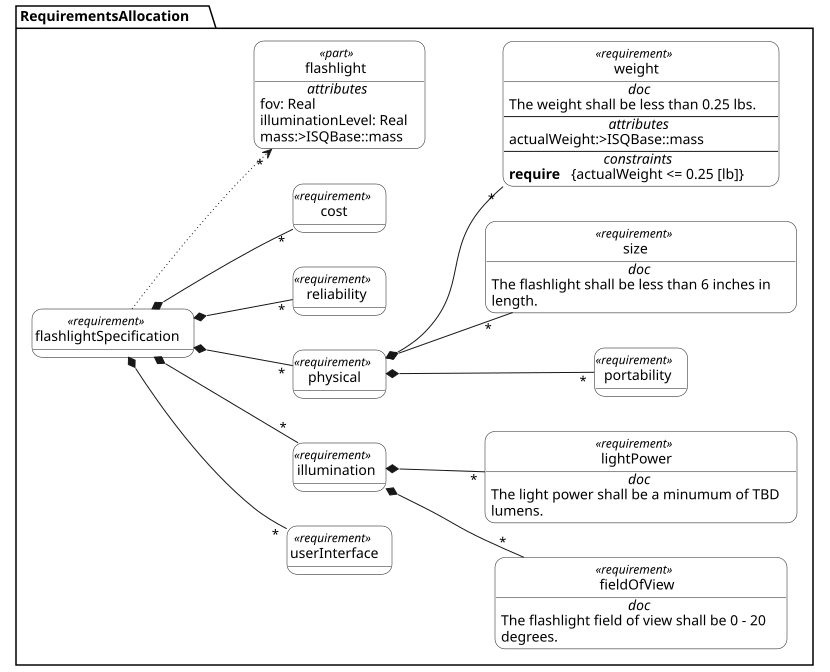

In [8]:
%viz --view tree --style lr Flashlight_StarterModel::SimplifiedViews::RequirementsAllocation